# P4CYGL processing

This Plasmidsaurus order was originally processed locally (Natascha's laptop). Excessive read duplication revealed a problem with the received files. Below is the reprocessing after Plasmidsaurus made changes to the files.

Reprocessing is started using AISynbioPipeline code on 12-10-25 on Poplar.

## Steps
1. Download, data organization, file renaming
2. Creating seqsamples and cross-checking in LIMS.
3. Short reads: QA/QC
4. (IN PROGRESS) Short reads: Breseq (refseq: ACN2586) and Breseq analysis
5. (TO DO) Long reads: QA/QC
6. (TO DO) Long reads: Blast analysis

## 0. Set-up

In [ ]:
## Make sure running in aisynbio_env

In [1]:
# Reload magic command to ensure that changes made to my imported modules are being picked up by the notebook continuously

%load_ext autoreload
%autoreload 2

In [265]:
import sys
import os

# Add project root to path for access to workflows and tasks
notebook_dir = os.getcwd()
project_root = os.path.dirname(notebook_dir)

if project_root not in sys.path:
    sys.path.insert(0, project_root)

In [3]:
import os

# Must add environment's bin to the PATH inside the notebook
env_bin = os.path.join(os.path.dirname(sys.executable), "")
os.environ["PATH"] = env_bin + ":" + os.environ["PATH"]

## 1. Download, file organization, renaming
- Create seqorder name and makedir into reception folder (/synbio/ai_synbio_data/experimental_data/downloads - should this be temporary?). Also make homedir to copy and view analysis reports.
- Download data into folder.
- Spot-check if duplicate read ID problem is fixed.
- Create new seqorder folder in experimental_data/sequencing_data/ and libraries.
- Copy all nanopore fastqs into long lib, renaming in the process.
- Copy all illumina fastqs into short lib, renaming in the process.
Creating sample seqs and cross-checking with LIMS


In [91]:
# Create seqorder name, make reception folder and seqorder analysis folder in nspahr homedir

from aisynbiopipeline.workflows.plasmidsaurus import create_seqorder_name
from aisynbiopipeline.workflows.seq_folder_utils import list_seqorders, SeqOrder, Library, SeqSample
import os

item_code = 'P4CYGL'
seqorder_name = create_seqorder_name(item_code)

reception_dir = '/storage/synbio/ai_synbio_data/experimental_data/downloads/' + seqorder_name
os.makedirs(reception_dir)
print(reception_dir)

home_dir = '/storage/nspahr/lib_analysis/' + seqorder_name
os.makedirs(home_dir)
print(home_dir)

/storage/nspahr/lib_analysis/Plasmidsaurus_2025-09-30_P4CYGL


In [8]:
# Download data into folder

from aisynbiopipeline.workflows.plasmidsaurus import get_access_token, download_results, get_credentials

CLIENT_ID = get_credentials("PLASMIDSAURUS_CLIENT_ID")
CLIENT_SECRET = get_credentials("PLASMIDSAURUS_CLIENT_SECRET")
access_token = get_access_token(CLIENT_ID, CLIENT_SECRET)
download_results(item_code, access_token, reception_dir)

ITEM P4CYGL
{'code': 'P4CYGL',
 'done_date': '2025-09-30T21:37:37.602680+00:00',
 'gross': 540.0,
 'order_name': '',
 'product_name': 'hybrid_extraction',
 'quantity': 3,
 'status': 'complete'}



DOWNLOADING READS FOR P4CYGL 


File downloaded successfully: /storage/synbio/ai_synbio_data/experimental_data/downloads/Plasmidsaurus_2025-09-30_P4CYGL/P4CYGL_reads.zip
Unzipping /storage/synbio/ai_synbio_data/experimental_data/downloads/Plasmidsaurus_2025-09-30_P4CYGL/P4CYGL_reads.zip to /storage/synbio/ai_synbio_data/experimental_data/downloads/Plasmidsaurus_2025-09-30_P4CYGL/P4CYGL_reads


In [9]:
os.listdir(reception_dir)

['P4CYGL_reads.zip', 'P4CYGL_reads']

In [16]:
# Spot-check if duplicate read ID problem is fixed

os.listdir(os.path.join(reception_dir, 'P4CYGL_reads'))

['P4CYGL_3_ANLstock.ACN2586.colony3_nanopore.fastq.gz',
 'P4CYGL_3_ANLstock.ACN2586.colony3_illumina_R1.fastq.gz',
 'P4CYGL_3_ANLstock.ACN2586.colony3_illumina_R2.fastq.gz',
 'P4CYGL_1_ANLstock.ACN2586.colony1_nanopore.fastq.gz',
 'P4CYGL_1_ANLstock.ACN2586.colony1_illumina_R1.fastq.gz',
 'P4CYGL_1_ANLstock.ACN2586.colony1_illumina_R2.fastq.gz',
 'P4CYGL_2_ANLstock.ACN2586.colony2_nanopore.fastq.gz',
 'P4CYGL_2_ANLstock.ACN2586.colony2_illumina_R1.fastq.gz',
 'P4CYGL_2_ANLstock.ACN2586.colony2_illumina_R2.fastq.gz']

In [14]:
!gunzip -c {os.path.join(reception_dir, 'P4CYGL_reads', 'P4CYGL_3_ANLstock.ACN2586.colony3_illumina_R1.fastq.gz')} | head

@LH00941:53:22CCH7LT1:1:1101:1351:1128 1:N:0:AGTCAGAC+TGTCGCTG
TTNAACAGCATTATGGCATAAGCGCCGTAATAGCCGTGTGTTTATGAATAAAAGCGTCGCTGAGATTAGCGAGATTCTGTTTAAAGAATGGCAAAATAGAAGTAGTTTATTTGCAGCGAGTTTAACGCTTGATTTAAGCGGACTTGCTCAA
+
II#IIIIIIIIIIIIIIIIIII9II9IIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIII9IIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIII9IIIIIIIIIIIIIIIIII9IIII9IIIIII
@LH00941:53:22CCH7LT1:1:1101:1407:1128 1:N:0:AGTCAGAC+TGTCGCTG
CANTATTCTCTGAATATAATGCTTTAAGATTGCCATTTATTCAGGCCTTAGTTACTCATTCAAAGCATCTTAGTGCTAACTATGTTAATTATGCAGATTCGAACTAATTTTTATTATATATAGTTCAAGAAAAGAATGAAATTATTAACTA
+
II#IIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIII9IIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIII9II9IIIIIIIIIIIIIIIIIII
@LH00941:53:22CCH7LT1:1:1101:1740:1128 1:N:0:AGTCAGAC+TGTCGCTG
GTNGTGTATCTCGTGCGTTTAGTCAGCTTGCAGTGGGTGACATTATCGAGATTTCACAACCACAAGGTGGCTTTTATCTTGAACCTAAAGCAGATGGCATTGTCCTGATTGCATCTGGAAGCGGAATAACGGCCATCTATGCTTTGCTACA

gzip: stdout: Broken pipe


In [15]:
!gunzip -c {os.path.join(reception_dir, 'P4CYGL_reads', 'P4CYGL_3_ANLstock.ACN2586.colony3_illumina_R1.fastq.gz')} | grep "@LH00941:53:22CCH7LT1:1:1101:1351:1128 1:N:0:AGTCAGAC+TGTCGCTG"

@LH00941:53:22CCH7LT1:1:1101:1351:1128 1:N:0:AGTCAGAC+TGTCGCTG


First read ID only occurs once. I assume that the duplication problem is fixed.

In [46]:
# Create new seqorder folder in experimental_data/sequencing_data/ and libraries

seqorder = SeqOrder(seqorder_name, create=True)
short = Library(seqorder, 'Illumina', create=True)
long = Library(seqorder, 'Nanopore', create=True)

In [48]:
# Identify Illumina/ Nanopore reads and copy into respective library folder

from pathlib import Path
import shutil

reads_path = Path(os.path.join(reception_dir, f'{item_code}_reads'))
i_pattern = "*illumina*.fastq.gz"
n_pattern = "*nanopore*.fastq.gz"
i_files = list(reads_path.glob(i_pattern))
n_files = list(reads_path.glob(n_pattern))

def rename_plasmidsaurus_read_file(file_name):
    aisynbio_filename = ('_').join(file_name.split('_')[2:])
    return aisynbio_filename

for file in i_files:
    plasmidsaurus_basename = os.path.basename(file)
    aisynbio_basename = rename_plasmidsaurus_read_file(plasmidsaurus_basename)
    shutil.copy2(reads_path/plasmidsaurus_basename, short.path/'received'/aisynbio_basename)

for file in n_files:
    plasmidsaurus_basename = os.path.basename(file)
    aisynbio_basename = rename_plasmidsaurus_read_file(plasmidsaurus_basename)
    shutil.copy2(reads_path/plasmidsaurus_basename, long.path/'received'/aisynbio_basename)

In [55]:
aisynbio_basename

'ANLstock.ACN2586.colony2_nanopore.fastq.gz'

## 2. Cross-checking this Plasmidsaurus order seqsamples in LIMS and creating SeqSamples.

In [388]:
# Import LIMS utilities (use util_simple.py for standalone LIMS API usage)
%run util_simple.py

✓ LIMS API loaded successfully


In [384]:
query_lims(
    'Measurements',
    filters={'Experiment': 'TFMN1', 'Type': 'Short_DNA_reads'}
)

""


In [385]:
# Check if the daemon is already running

from aisynbiopipeline.limsapi.sync import stop_sync_daemon, start_sync_daemon, sync_all_sheets

stop_sync_daemon()

Exception: Sync daemon is not running

In [455]:
from aisynbiopipeline.limsapi.config import get_db_path

get_db_path()

PosixPath('/storage/synbio/lims_mirror.backup.db')

In [456]:
# Run a manual sync

from aisynbiopipeline.limsapi.sync import sync_all_sheets

sync_all_sheets()

2025-12-15 18:30:35,109 - lims_sync - INFO - Starting sync operation
2025-12-15 18:30:35,110 - lims_sync - INFO - Connecting to Google Sheets
2025-12-15 18:30:36,659 - lims_sync - INFO - Connecting to database
2025-12-15 18:30:36,908 - lims_sync - INFO - Found 12 worksheets: Experiments, Strains, Conditions, Samples, Measurements, Genes, Measurement_types, DNA_constructs, Primers, dgoA_alleles_new, dgoA_alleles_old, robotic_mt_samples
2025-12-15 18:30:36,909 - lims_sync - INFO - Syncing worksheet: Experiments
2025-12-15 18:30:38,159 - lims_sync - INFO - Retrieved 6 rows from Experiments
2025-12-15 18:30:38,219 - lims_sync - INFO - Inserted 6, updated 0 rows in Experiments
2025-12-15 18:30:43,227 - lims_sync - INFO - Syncing worksheet: Strains
2025-12-15 18:30:44,449 - lims_sync - INFO - Retrieved 1020 rows from Strains
2025-12-15 18:30:44,532 - lims_sync - INFO - Inserted 1020, updated 0 rows in Strains
2025-12-15 18:30:49,581 - lims_sync - INFO - Syncing worksheet: Conditions
2025-12-

{'start_time': '2025-12-15T18:30:35.108968',
 'end_time': '2025-12-15T18:31:50.724951',
 'success': True,
 'tables_synced': 11,
 'total_rows_inserted': 5706,
 'total_rows_updated': 0,
 'total_rows_deleted': 0,
 'errors': ["Error syncing worksheet robotic_mt_samples: Failed to get worksheet data: the header row in the worksheet contains duplicates: ['']To manually set the header row, use the `expected_headers` parameter of `get_all_records()`"]}

In [459]:
# Start daemon sync
from aisynbiopipeline.limsapi.sync import start_sync_daemon

start_sync_daemon()

2025-12-15 18:33:13,878 - lims_sync - INFO - Sync daemon started with 10 minute interval
2025-12-15 18:33:13,880 - lims_sync - INFO - Starting sync operation
2025-12-15 18:33:13,883 - lims_sync - INFO - Connecting to Google Sheets
2025-12-15 18:33:14,295 - lims_sync - INFO - Connecting to database
2025-12-15 18:33:14,478 - lims_sync - INFO - Found 12 worksheets: Experiments, Strains, Conditions, Samples, Measurements, Genes, Measurement_types, DNA_constructs, Primers, dgoA_alleles_new, dgoA_alleles_old, robotic_mt_samples
2025-12-15 18:33:14,479 - lims_sync - INFO - Syncing worksheet: Experiments
2025-12-15 18:33:15,508 - lims_sync - INFO - Retrieved 6 rows from Experiments
2025-12-15 18:33:15,530 - lims_sync - INFO - Inserted 6, updated 0 rows in Experiments
2025-12-15 18:33:20,537 - lims_sync - INFO - Syncing worksheet: Strains
2025-12-15 18:33:21,442 - lims_sync - INFO - Retrieved 1020 rows from Strains
2025-12-15 18:33:21,511 - lims_sync - INFO - Inserted 1020, updated 0 rows in St

In [457]:
query_lims(
    'Measurements',
    filters={'Experiment': 'TFMN1', 'Type': 'Short_DNA_reads'}
)

,Database_ID,Name,Type,Experiment,Sample_ID,Protocol,Who_measured,Lab,Timestamp,Data,Error,Comments,deleted,last_synced,row_hash
0,,TFMN1.fba.1.T1.P,Short_DNA_reads,TFMN1,TFMN1.fba.1,,Paul Hanke & technicians,ANL & Plasmidsaurus,,,incomplete,,0,2025-12-15T18:31:01.962511,dcf972b44218edc2f7da00d8cabc590b0bf571172ead65...
1,,TFMN1.sohB.1.T1.P,Short_DNA_reads,TFMN1,TFMN1.sohB.1,,Paul Hanke & technicians,ANL & Plasmidsaurus,,,incomplete,,0,2025-12-15T18:31:01.962540,2d3575793390a0c7cc5d6e4596b475910aaa8edf6540b7...
2,,TFMN1.pgi.1.T1.P,Short_DNA_reads,TFMN1,TFMN1.pgi.1,,Paul Hanke & technicians,ANL & Plasmidsaurus,,,incomplete,,0,2025-12-15T18:31:01.962568,26db1ede424d205022704b7bc772c3d133c35bc1455ceb...
3,,TFMN1.fba.tpiA.1.T1.P,Short_DNA_reads,TFMN1,TFMN1.fba.tpiA.1,,Paul Hanke & technicians,ANL & Plasmidsaurus,,,incomplete,,0,2025-12-15T18:31:01.962596,f39a7836b9fa9741118c3790901986358c58c885447e9a...
4,,TFMN1.pgi.tpiA.1.T1.P,Short_DNA_reads,TFMN1,TFMN1.pgi.tpiA.1,,Paul Hanke & technicians,ANL & Plasmidsaurus,,,incomplete,,0,2025-12-15T18:31:01.962624,624f2a438463f807d01f2d648b9a4d940f1976608d2678...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
204,,TFMN1.fba.pgi.2.T32.S2,Short_DNA_reads,TFMN1,TFMN1.fba.pgi.2,,Paul Hanke & technicians,ANL & Plasmidsaurus,,,incomplete,,0,2025-12-15T18:31:01.968111,3370badbddab2a844fa52a2d9a8295e4f3daefeeac9506...
205,,TFMN1.sohB.4.T32.S1,Short_DNA_reads,TFMN1,TFMN1.sohB.4,,Paul Hanke & technicians,ANL & Plasmidsaurus,,,incomplete,,0,2025-12-15T18:31:01.968138,3ebcb7632499fa86fe0b221d2f9622fecfab9959236e3f...
206,,TFMN1.sohB.4.T32.S2,Short_DNA_reads,TFMN1,TFMN1.sohB.4,,Paul Hanke & technicians,ANL & Plasmidsaurus,,,incomplete,,0,2025-12-15T18:31:01.968165,30ef60820e9ba2e3ab1bf25cb5e8ed4b2d1096539d6254...
207,,TFMN1.sohB.5.T32.S1,Short_DNA_reads,TFMN1,TFMN1.sohB.5,,Paul Hanke & technicians,ANL & Plasmidsaurus,,,incomplete,,0,2025-12-15T18:31:01.968192,98bf65979e2f725eed18e01ccfaf58cac44e93b11f1481...


Synced successfully.
I want to move the sync log into /storage/synbio instead of keeping it witht the repo. So I will stop the daemon, move the sync file and change the config path to the sync file, then restart the daemon.

In [462]:
# Stop sync daemon
from aisynbiopipeline.limsapi.sync import stop_sync_daemon

stop_sync_daemon()

In [463]:
# Re-start daemon sync
from aisynbiopipeline.limsapi.sync import start_sync_daemon

start_sync_daemon()

2025-12-15 21:07:50,796 - lims_sync - INFO - Sync daemon started with 10 minute interval
2025-12-15 21:07:50,814 - lims_sync - INFO - Starting sync operation
2025-12-15 21:07:50,815 - lims_sync - INFO - Connecting to Google Sheets
2025-12-15 21:07:51,133 - lims_sync - INFO - Connecting to database
2025-12-15 21:07:51,289 - lims_sync - INFO - Found 12 worksheets: Experiments, Strains, Conditions, Samples, Measurements, Genes, Measurement_types, DNA_constructs, Primers, dgoA_alleles_new, dgoA_alleles_old, robotic_mt_samples
2025-12-15 21:07:51,290 - lims_sync - INFO - Syncing worksheet: Experiments
2025-12-15 21:07:52,105 - lims_sync - INFO - Retrieved 6 rows from Experiments
2025-12-15 21:07:52,156 - lims_sync - INFO - Inserted 6, updated 0 rows in Experiments
2025-12-15 21:07:57,241 - lims_sync - INFO - Syncing worksheet: Strains
2025-12-15 21:07:58,019 - lims_sync - INFO - Retrieved 1020 rows from Strains
2025-12-15 21:07:58,083 - lims_sync - INFO - Inserted 1020, updated 0 rows in St

In [464]:
# Manually archive the database:
from aisynbiopipeline.limsapi.archive import create_archive

create_archive()

'/storage/synbio/archive/lims_manual_20251215_211322.db.gz'

In [607]:
# Manually archive the database:
from aisynbiopipeline.limsapi.archive import create_archive

create_archive()

KeyboardInterrupt: 

In [87]:
# Querying LIMS for desired sequencing measurements

thisExpLIMSseqsamples_short = query_lims(
    'Measurements',
    filters={'Experiment': 'strain_stocks', 'Type': 'Short_DNA_reads'}
)['Name'].apply(lambda x: x.replace('.Short_DNA_reads', '')).to_list()

thisExpLIMSseqsamples_long = query_lims(
    'Measurements',
    filters={'Experiment': 'strain_stocks', 'Type': 'Long_DNA_reads'}
)['Name'].apply(lambda x: x.replace('.Long_DNA_reads', '')).to_list()

In [88]:
# Cross-checking seq sample measurement names

short_manifest = short.create_manifest('received')
print(f"Are all short Plasmidsaurus seqsamples from order {item_code} in the LIMS?")
print(all([x in thisExpLIMSseqsamples_short for x in short_manifest['sample_name'].to_list()]))
print(f"Are all short LIMS seqsamples with selected filters in Plasmidsaurus order {item_code}?")
print(all([x in short_manifest['sample_name'].to_list() for x in thisExpLIMSseqsamples_short]))

long_manifest = long.create_manifest('received')
print(f"Are all Plasmidsaurus long seqsamples from order {item_code} in the LIMS?")
print(all([x in thisExpLIMSseqsamples_long for x in long_manifest['sample_name'].to_list()]))
print(f"Are all LIMS long seqsamples with selected filters in Plasmidsaurus order {item_code}?")
print(all([x in long_manifest['sample_name'].to_list() for x in thisExpLIMSseqsamples_long]))

Are all short Plasmidsaurus seqsamples from order P4CYGL in the LIMS?
True
Are all short LIMS seqsamples with selected filters in Plasmidsaurus order P4CYGL?
False
Are all Plasmidsaurus long seqsamples from order P4CYGL in the LIMS?
True
Are all LIMS long seqsamples with selected filters in Plasmidsaurus order P4CYGL?
False


In [89]:
# Creating batch (list) of seqsamples for this seqorder

shortSeqSamples = [SeqSample(short, row['sample_name']) for _, row in short_manifest.iterrows()]

## 3. Short reads: QA/QC

- fastp (Celery): Must start running workers first
- MultiQC

In [120]:
# Create trimmed dir

short.create_subfolder('trimmed')

Running one fastp worker:


(aisynbio_env) nspahr@seed:~/code/AISynbioPipeline$ python -m aisynbiopipeline.tasks.fastp_task 1
======================================================================
Starting fastp Celery Worker
======================================================================

Monitor at: http://poplar.cels.anl.gov:5555
======================================================================

 
 -------------- fastp_1@seed.jupyter v5.6.0 (recovery)
--- ***** ----- 
-- ******* ---- Linux-6.11.0-21-generic-x86_64-with-glibc2.39 2025-12-11 20:22:39
- *** --- * --- 
- ** ---------- [config]
- ** ---------- .> app:         fastp:0x71bd709f79e0
- ** ---------- .> transport:   redis://bioseed_redis:6379/10
- ** ---------- .> results:     redis://bioseed_redis:6379/10
- *** --- * --- .> concurrency: 2 (prefork)
-- ******* ---- .> task events: OFF (enable -E to monitor tasks in this worker)
--- ***** ----- 
 -------------- [queues]
                .> fastp            exchange=fastp(direct) key=fastp

In [109]:
from celery import Celery
import os

# Create Celery client
client = Celery(
    'client',
    broker=os.getenv('CELERY_BROKER_URL', 'redis://bioseed_redis:6379/10'),
    backend=os.getenv('CELERY_RESULT_BACKEND', 'redis://bioseed_redis:6379/10')
)

In [110]:
# Where should this code go?

from pathlib import Path

def get_fastp_params(library, seqsample):

    fwd_in_path = seqsample.received[0]
    fwd_in_file = os.path.basename(fwd_in_path)
    fwd_out_file = fwd_in_file.replace('.fastq.gz', '_trimmed.fastq.gz')
    fwd_out_path = os.path.join(library.path, 'trimmed', fwd_out_file)
    rvs_in_path = seqsample.received[1]
    rvs_in_file = os.path.basename(rvs_in_path)
    rvs_out_file = rvs_in_file.replace('.fastq.gz', '_trimmed.fastq.gz')
    rvs_out_path = os.path.join(library.path, 'trimmed', rvs_out_file)
    
    # Normalize Path → str - Celery tasks only accept certain input data types.
    def norm(x): return str(x) if isinstance(x, Path) else x
    
    fastp_params = {
        'path_to_fwd': norm(fwd_in_path),
        'path_to_rev': norm(rvs_in_path),
        'path_to_fwd_out': norm(fwd_out_path),
        'path_to_rev_out': norm(rvs_out_path),
        'threads': 16,
        'polyG':5
    }

    return fastp_params

In [122]:
# Submit tasks:

results = []

for sample in seqsamples:
    result = client.send_task(
        'fastp.run',
        kwargs=get_fastp_params(short, sample),
        queue='fastp'
    )
    results.append(result)

In [126]:
for i in results:
    print(i.status)

SUCCESS
SUCCESS
SUCCESS


In [134]:
from aisynbiopipeline.workflows.read_qc import run_multiqc
import shutil

multiqc_report = run_multiqc(short.path / 'trimmed')
multiqc_report_dir = os.path.dirname(multiqc_report)
multiqc_report_file = os.path.basename(multiqc_report)
dst_multiqc_report_file = os.path.join(home_dir, 'trimmed_' + multiqc_report_file)
shutil.copy(multiqc_report, dst_multiqc_report_file)


/// ]8;id=110791;https://multiqc.info\MultiQC]8;;\ v1.32

     version_check | MultiQC Version v1.33 now available!
       file_search | Search path: /storage/synbio/ai_synbio_data/experimental_data/sequencing_orders/Plasmidsaurus_2025-09-30_P4CYGL/Plasmidsaurus_2025-09-30_P4CYGL_Illumina/trimmed
             fastp | Found 3 reports


        searching | ████████████████████████████████████████ 100% 13/13                                                   html

     write_results | Data        : multiqc_data   (overwritten)
     write_results | Report      : multiqc_report.html   (overwritten)
           multiqc | MultiQC complete


'/storage/nspahr/lib_analysis/Plasmidsaurus_2025-09-30_P4CYGL/trimmed_multiqc_report.html'

## 4. Short reads: Breseq (refseq: ACN2586)

- Run breseq on all illumina seqsamples.
- Create breseq objects for each seqsample and aggregate summary counts.
- Generate mutation table for all samples and write to csv for import into Google Sheets.
- 

Started two breseq workers:

aisynbio_env) nspahr@seed:~/code/AISynbioPipeline$ python -m aisynbiopipeline.tasks.breseq_task 1
======================================================================
Starting breseq Celery Worker
======================================================================

Monitor at: http://poplar.cels.anl.gov:5555
======================================================================

 
 -------------- breseq_1@seed.jupyter v5.6.0 (recovery)
--- ***** ----- 
-- ******* ---- Linux-6.11.0-21-generic-x86_64-with-glibc2.39 2025-12-09 23:29:03
- *** --- * --- 
- ** ---------- [config]
- ** ---------- .> app:         breseq:0x7f7c139263c0
- ** ---------- .> transport:   redis://bioseed_redis:6379/10
- ** ---------- .> results:     redis://bioseed_redis:6379/10
- *** --- * --- .> concurrency: 2 (prefork)
-- ******* ---- .> task events: OFF (enable -E to monitor tasks in this worker)
--- ***** ----- 
 -------------- [queues]
                .> breseq           exchange=breseq(direct) key=breseq



(aisynbio_env) nspahr@seed:~/code/AISynbioPipeline$ python -m aisynbiopipeline.tasks.breseq_task 2
======================================================================
Starting breseq Celery Worker
======================================================================

Monitor at: http://poplar.cels.anl.gov:5555
======================================================================

 
 -------------- breseq_2@seed.jupyter v5.6.0 (recovery)
--- ***** ----- 
-- ******* ---- Linux-6.11.0-21-generic-x86_64-with-glibc2.39 2025-12-09 23:29:11
- *** --- * --- 
- ** ---------- [config]
- ** ---------- .> app:         breseq:0x7a8f4dd577a0
- ** ---------- .> transport:   redis://bioseed_redis:6379/10
- ** ---------- .> results:     redis://bioseed_redis:6379/10
- *** --- * --- .> concurrency: 2 (prefork)
-- ******* ---- .> task events: OFF (enable -E to monitor tasks in this worker)
--- ***** ----- 
 -------------- [queues]
                .> breseq           exchange=breseq(direct) key=breseq

In [276]:
# Create breseq dir

short.create_subfolder('breseq')

In [139]:
# List available reference genomes

from aisynbiopipeline.workflows.breseq import list_reference_genomes

list_reference_genomes()

['ADP1_Neidle_CDM.gbk', 'ACN2821_CDM.gbk', 'ACN2586_NSS.gbk']

In [277]:
# Where should this code go?

# Specifies and assigns breseq parameters

def get_breseq_params(seqsample):

    # Normalize Path → str - Celery tasks only accept certain input data types.
    def norm(x): return str(x) if isinstance(x, Path) else x
    
    breseq_params = {
        'read_paths': [norm(x) for x in seqsample.trimmed],
        'breseq_folder': norm(seqsample.breseq),
        'reference': 'ACN2586_NSS.gbk',
        'polymorphism_prediction': True,
        'limit_fold_coverage': 300,
        'num_processors': 4
    }
    return breseq_params

In [278]:
# Submit tasks

results = []
for sample in shortSeqSamples:
    result = client.send_task(
        'breseq.run',
        kwargs=get_breseq_params(sample),
        queue='breseq'
    )
    results.append(result)

In [292]:
for i in results:
    print(i.status)
    # print(i.result['output'])

SUCCESS
SUCCESS
SUCCESS


In [221]:
# Where should this go?

def parse_seqsample_name(seqsample_name):
    
    import re

    pattern = re.compile(
        r'TFMN1\.(sohB.pgi|fba.pgi|fba.sohB|sohB.tpiA|fba.tpiA|pgi.tpiA|fba|tpiA|sohB|noDNA|pgi)\.([1-5])\.T(\d{1,2})\.([PSL])([123])?$'
    )

    match = re.match(pattern, seqsample_name)

    if match:
        construct = match.group(1)
        replicate = match.group(2)
        transfer = match.group(3)
        isolate = match.group(4)
        colony_num = match.group(5)

    else:
        construct = 'NA'
        replicate = 'NA'
        transfer = 'NA'
        isolate = 'NA'
        colony_num = 'NA'

    return {'construct': construct, 'replicate': replicate, 'transfer': transfer, 'isolate': isolate, 'colony_num': colony_num}
        

In [293]:
# Create breseq objects for each seqsample and aggregate summary counts

breseq_objects = []

for i in results:
    breseq_folder = i.result['output']
    b = Breseq.from_existing(breseq_folder)
    breseq_objects.append(b)

rows = []

for b in breseq_objects:
    
    row = {}
    
    try:
        b.count_reads()
        b.count_mutations()
    except Exception as e:
        row.update({'seqsample': getattr(b, 'title', None)})
        row.update(parse_seqsample_name(getattr(b, 'title', None)))
        row.update({'error': str(e),
                    'input_read_count': None,
                    'used_read_count': None,
                    'mapped_read_count': None,
                    'consensus_mutation_count': None,
                    'polymorphism_mutation_count': None,}
                    )
        rows.append(row)
        print(f"Error loading Breseq from {b.title}: {e}")
        continue

    row['seqsample'] = getattr(b, 'title', None)
    row.update(parse_seqsample_name(getattr(b, 'title', None)))
    row['error'] = None
    row['input_read_count'] = getattr(b, 'input_read_count', None)
    row['used_read_count'] = getattr(b, 'used_read_count', None)
    row['mapped_read_count'] = getattr(b, 'mapped_read_count', None)
    row['consensus_mutation_count'] = getattr(b, 'consensus_mutation_count', None)
    row['polymorphism_mutation_count'] = getattr(b, 'polymorphism_mutation_count', None)

    rows.append(row)

df = pd.DataFrame(rows)
df

,seqsample,construct,replicate,transfer,isolate,colony_num,error,input_read_count,used_read_count,mapped_read_count,consensus_mutation_count,polymorphism_mutation_count
0,ANLstock.ACN2586.colony1,NA,NA,NA,NA,NA,None,20780345,7305308,7203955,3,211
1,ANLstock.ACN2586.colony2,NA,NA,NA,NA,NA,None,26081581,7318275,7201682,4,213
2,ANLstock.ACN2586.colony3,NA,NA,NA,NA,NA,None,20967674,7334979,7235264,3,209


In [294]:
from aisynbiopipeline.workflows.breseq import compare_gdiff

reference = 'ACN2586_NSS.gbk'
gdiffs = [b.gd_file for b in breseq_objects]

table_format = 'html'
outfile = os.path.join(home_dir, f'all_mutations_{item_code}.{table_format}')
html = compare_gdiff(reference, outfile, gdiffs, format=table_format)

table_format = 'csv'
outfile = os.path.join(home_dir, f'all_mutations_{item_code}.{table_format}')
csv = compare_gdiff(reference, outfile, gdiffs, format=table_format)

breseq 0.39.0     http://barricklab.org/breseq

Active Developers: Barrick JE, Deatherage DE
Contact:           <jeffrey.e.barrick@gmail.com>

breseq is free software; you can redistribute it and/or modify it under the
terms the GNU General Public License as published by the Free Software 
Foundation; either version 2, or (at your option) any later version.

Copyright (c) 2008-2010 Michigan State University
Copyright (c) 2011-2022 The University of Texas at Austin

If you use breseq in your research, please cite:

  Deatherage, D.E., Barrick, J.E. (2014) Identification of mutations
  in laboratory-evolved microbes from next-generation sequencing
  data using breseq. Methods Mol. Biol. 1151: 165–188.

If you use structural variation (junction) predictions, please cite:

  Barrick, J.E., Colburn, G., Deatherage D.E., Traverse, C.C.,
  Strand, M.D., Borges, J.J., Knoester, D.B., Reba, A., Meyer, A.G. 
  (2014) Identifying structural variation in haploid microbial genomes 
  from short-rea

In [359]:
compare_df = pd.read_csv(csv)

All of the following transformations should possibly go into a different script...

In [351]:
# Set display options
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', 50)

In [360]:
cols_with_diff_vals_for_same_mutation = ['new_read_count', 'new_read_count_basis', 'ref_read_count',
     'ref_read_count_basis', 'multiple_polymorphic_SNPs_in_same_codon',
     'repeat_new_copies', 'repeat_ref_copies'
    ]
cols_uninformative = ['clone', 'mutator_status', 'population', 'time', 'treatment']
cols_to_keep = [col for col in compare_df.columns.to_list() if (col not in cols_with_diff_vals_for_same_mutation) and (col not in cols_uninformative)]

compare_df = compare_df[cols_to_keep]

In [345]:
# compare_df['experiment'] = compare_df['title'].apply(lambda x: x.split('.')[0])
# compare_df['strain'] = compare_df['title'].apply(lambda x: x.split('.')[1])
# compare_df['colony'] = compare_df['title'].apply(lambda x: x.split('.')[2])

/tmp/ipykernel_1631511/2091122652.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  compare_df['experiment'] = compare_df['title'].apply(lambda x: x.split('.')[0])
/tmp/ipykernel_1631511/2091122652.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  compare_df['strain'] = compare_df['title'].apply(lambda x: x.split('.')[1])
/tmp/ipykernel_1631511/2091122652.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value inst

In [361]:
compare_df.head()

,aa_new_seq,aa_position,aa_ref_seq,codon_new_seq,codon_number,codon_position,codon_position_is_indeterminate,codon_ref_seq,frequency,gene_name,gene_position,gene_product,gene_strand,genes_inactivated,genes_overlapping,genes_promoter,insert_position,locus_tag,locus_tags_inactivated,locus_tags_overlapping,locus_tags_promoter,mutation_category,new_seq,position,position_end,position_start,ref_seq,repeat_length,repeat_seq,seq_id,size,snp_type,title,transl_table,type
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.500009,ACIAD_RS05320/ACIAD_RS05325,intergenic (+6/-537),tRNA-Ser/efflux RND transporter periplasmic ad...,>/>,NaN,NaN,NaN,NaN,ACIAD_RS05320/ACIAD_RS05325,NaN,NaN,NaN,snp_intergenic,T,1148145,1148145,1148145,C,NaN,NaN,ACN2586_NSS,NaN,intergenic,ANLstock.ACN2586.colony1,NaN,SNP
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.437497,ACIAD_RS05320/ACIAD_RS05325,intergenic (+11/-532),tRNA-Ser/efflux RND transporter periplasmic ad...,>/>,NaN,NaN,NaN,NaN,ACIAD_RS05320/ACIAD_RS05325,NaN,NaN,NaN,snp_intergenic,T,1148150,1148150,1148150,A,NaN,NaN,ACN2586_NSS,NaN,intergenic,ANLstock.ACN2586.colony1,NaN,SNP
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.379468,ACIAD_RS08245/ACIAD_RS08250,intergenic (+134/-53),cold-shock protein/type VI secretion system Vg...,>/>,NaN,NaN,ACIAD_RS08250,NaN,ACIAD_RS08245/ACIAD_RS08250,NaN,NaN,ACIAD_RS08250,snp_intergenic,A,1798244,1798244,1798244,G,NaN,NaN,ACN2586_NSS,NaN,intergenic,ANLstock.ACN2586.colony1,NaN,SNP
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.381166,ACIAD_RS08245/ACIAD_RS08250,intergenic (+137/-50),cold-shock protein/type VI secretion system Vg...,>/>,NaN,NaN,ACIAD_RS08250,NaN,ACIAD_RS08245/ACIAD_RS08250,NaN,NaN,ACIAD_RS08250,snp_intergenic,C,1798247,1798247,1798247,G,NaN,NaN,ACN2586_NSS,NaN,intergenic,ANLstock.ACN2586.colony1,NaN,SNP
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.377748,ACIAD_RS08245/ACIAD_RS08250,intergenic (+138/-49),cold-shock protein/type VI secretion system Vg...,>/>,NaN,NaN,ACIAD_RS08250,NaN,ACIAD_RS08245/ACIAD_RS08250,NaN,NaN,ACIAD_RS08250,snp_intergenic,G,1798248,1798248,1798248,A,NaN,NaN,ACN2586_NSS,NaN,intergenic,ANLstock.ACN2586.colony1,NaN,SNP


Next, reshape (pivot) the table by grouping by these columns, so that only title (sample) remain as columns (values are the mutation frequencies).
Reindex.
Now ready to analyze

In [506]:
index = [col for col in compare_df.columns if (col!='title') and (col!='frequency')]

df = compare_df.pivot(index=index, columns = 'title', values = 'frequency').sort_index(level='position')
df = df.fillna(0)
df.head()

title                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                         ANLstock.ACN2586.colony1  \
aa_new_seq aa_position aa_ref_seq codon_new_seq codon_number codon_position codon_position_is_indeterminate codon_ref_seq gene_name                   gene_position         gene_product                                       gene_strand genes_inactivated genes_overlapping genes_promoter insert_position locus_tag                   locus_tags_inactivated locus_tags_overlapping locus_tags_promoter mutation_category new_seq position position_end position_start ref_seq repeat_length repeat_seq seq_id      size snp_type      transl_table type                             
I          145.0       N          ATC           145.0        2.0            NaN                             AAC           nuoH                        434                   NADH-quinone oxidoreductase subunit NuoH           >           NaN               nuoH              NaN            NaN             ACIAD_RS03370               NaN                    ACIAD_RS03370          NaN                 snp_nonsynonymous T       722360   722360       722360         A       NaN           NaN        ACN2586_NSS NaN  nonsynonymous 11.0         SNP                   0.000000   
NaN        NaN         NaN        NaN           NaN          NaN            NaN                             NaN           ACIAD_RS04985               coding (2/1599 nt)    isocitrate lyase                                   >           ACIAD_RS04985     NaN               NaN            NaN             ACIAD_RS04985               ACIAD_RS04985          NaN                    NaN                 small_indel       NaN     1079899  1079899      1079899        T       NaN           NaN        ACN2586_NSS 1.0  NaN           NaN          DEL                   0.000000   
                                                                                                                          ACIAD_RS05320/ACIAD_RS05325 intergenic (+6/-537)  tRNA-Ser/efflux RND transporter periplasmic ada... >/>         NaN               NaN               NaN            NaN             ACIAD_RS05320/ACIAD_RS05325 NaN                    NaN                    NaN                 snp_intergenic    T       1148145  1148145      1148145        C       NaN           NaN        ACN2586_NSS NaN  intergenic    NaN          SNP                   0.500009   
                                                                                                                                                      intergenic (+11/-532) tRNA-Ser/efflux RND transporter periplasmic ada... >/>         NaN               NaN               NaN            NaN             ACIAD_RS05320/ACIAD_RS05325 NaN                    NaN                    NaN                 snp_intergenic    T       1148150  1148150      1148150        A       NaN           NaN        ACN2586_NSS NaN  intergenic    NaN          SNP                   0.437497   
                                                                                                                          ACIAD_RS08245/ACIAD_RS08250 intergenic (+134/-53) cold-shock protein/type VI secretion system Vgr... >/>         NaN               NaN               ACIAD_RS08250  NaN             ACIAD_RS08245/ACIAD_RS08250 NaN                    NaN                    ACIAD_RS08250       snp_intergenic    A       1798244  1798244      1798244        G       NaN           NaN        ACN2586_NSS NaN  intergenic    NaN          SNP                   0.379468   

title    

In [395]:
# Consensus mutations (100%) in any of the samples

df.loc[(df == 1).any(axis=1)].reset_index()[['position', 'locus_tag', 'gene_name', 'gene_product', 'mutation_category'] + samples]

title,position,locus_tag,gene_name,gene_product,mutation_category,ANLstock.ACN2586.colony1,ANLstock.ACN2586.colony2,ANLstock.ACN2586.colony3
0,2327281,ACIAD_RS10830,rsmG,16S rRNA (guanine(527)-N(7))-methyltransferase...,snp_nonsense,1.0,1.0,1.0
1,2735141,ACIAD_RS12595,ACIAD_RS12595,DUF637 domain-containing protein,snp_synonymous,1.0,1.0,1.0
2,2738312,ACIAD_RS12600/ACIAD_RS17115,ACIAD_RS12600/ACIAD_RS17115,ShlB/FhaC/HecB family hemolysin secretion/acti...,small_indel,1.0,1.0,1.0
3,2883691,ACIAD_RS13325,ACIAD_RS13325,valine--tRNA ligase,snp_nonsynonymous,0.0,1.0,0.0


In [394]:
# Consensus mutations (100%) in all of the samples

df.loc[(df == 1).all(axis=1)].reset_index()[['position', 'locus_tag', 'gene_name', 'gene_product', 'mutation_category'] + samples]

title,position,locus_tag,gene_name,gene_product,mutation_category,ANLstock.ACN2586.colony1,ANLstock.ACN2586.colony2,ANLstock.ACN2586.colony3
0,2327281,ACIAD_RS10830,rsmG,16S rRNA (guanine(527)-N(7))-methyltransferase...,snp_nonsense,1.0,1.0,1.0
1,2735141,ACIAD_RS12595,ACIAD_RS12595,DUF637 domain-containing protein,snp_synonymous,1.0,1.0,1.0
2,2738312,ACIAD_RS12600/ACIAD_RS17115,ACIAD_RS12600/ACIAD_RS17115,ShlB/FhaC/HecB family hemolysin secretion/acti...,small_indel,1.0,1.0,1.0


Next, format df like html table, then write out to csv and view in google sheets.

In [380]:
if len(set([os.path.basename(b.output_folder) for b in breseq_objects])) == 1:
    version_name = list(set([os.path.basename(b.output_folder) for b in breseq_objects]))[0]
else:
    version_name = None
    print("Warning: Not all breseq_objects were run with identical parameters.")

In [383]:
# Decided against formatting like the html table. Will show to group and let them decide which of the cols are important

df.to_csv(os.path.join(home_dir, f'mutation_comparison_{item_code}_{version_name}_reformatted.csv'))

Because there might be many many samples in this comparison, define sample set.

In [439]:
samples = ['ANLstock.ACN2586.colony1', 'ANLstock.ACN2586.colony2', 'ANLstock.ACN2586.colony3']
sample_order = list(range(3))
sample_set = dict(zip(sample_order, samples))
sample_set

{0: 'ANLstock.ACN2586.colony1',
 1: 'ANLstock.ACN2586.colony2',
 2: 'ANLstock.ACN2586.colony3'}

In [366]:
df_set = df[list(sample_set.values())]

In [367]:
df_set

title                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                         ANLstock.ACN2586.colony1  \
aa_new_seq aa_position aa_ref_seq codon_new_seq codon_number codon_position codon_position_is_indeterminate codon_ref_seq gene_name                   gene_position            gene_product                                       gene_strand genes_inactivated genes_overlapping genes_promoter insert_position locus_tag                   locus_tags_inactivated locus_tags_overlapping locus_tags_promoter mutation_category new_seq position position_end position_start ref_seq              repeat_length repeat_seq seq_id      size snp_type      transl_table type                             
I          145.0       N          ATC           145.0        2.0            NaN                             AAC           nuoH                        434                      NADH-quinone oxidoreductase subunit NuoH           >           NaN               nuoH              NaN            NaN             ACIAD_RS03370               NaN                    ACIAD_RS03370          NaN                 snp_nonsynonymous T       722360   722360       722360         A                    NaN           NaN        ACN2586_NSS NaN  nonsynonymous 11.0         SNP                   0.000000   
NaN        NaN         NaN        NaN           NaN          NaN            NaN                             NaN           ACIAD_RS04985               coding (2/1599 nt)       isocitrate lyase                                   >           ACIAD_RS04985     NaN               NaN            NaN             ACIAD_RS04985               ACIAD_RS04985          NaN                    NaN                 small_indel       NaN     1079899  1079899      1079899        T                    NaN           NaN        ACN2586_NSS 1.0  NaN           NaN          DEL                   0.000000   
                                                                                                                          ACIAD_RS05320/ACIAD_RS05325 intergenic (+6/-537)     tRNA-Ser/efflux RND transporter periplasmic ada... >/>         NaN               NaN               NaN            NaN             ACIAD_RS05320/ACIAD_RS05325 NaN                    NaN                    NaN                 snp_intergenic    T       1148145  1148145      1148145        C                    NaN           NaN        ACN2586_NSS NaN  intergenic    NaN          SNP                   0.500009   
                                                                                                                                                      intergenic (+11/-532)    tRNA-Ser/efflux RND transporter periplasmic ada... >/>         NaN               NaN               NaN            NaN             ACIAD_RS05320/ACIAD_RS05325 NaN                    NaN                    NaN                 snp_intergenic    T       1148150  1148150      1148150        A                    NaN           NaN        ACN2586_NSS NaN  intergenic    NaN          SNP                   0.437497   
                                                                                                                          ACIAD_RS08245/ACIAD_RS08250 intergenic (+134/-53)    cold-shock protein/type VI secretion system Vgr... >/>         NaN               NaN               ACIAD_RS08250  NaN             ACIAD_RS08245/ACIAD_RS08250 NaN                    NaN                    ACIAD_RS08250       snp_intergenic    A       1798244  1798244      1798244        G                    N

Show fixed mutations present in all samples of sample set

In [391]:
df[(df == 1).all(axis=1)].reset_index()[['position', 'locus_tag', 'gene_name', 'gene_product', 'mutation_category'] + samples]

title,position,locus_tag,gene_name,gene_product,mutation_category,ANLstock.ACN2586.colony1,ANLstock.ACN2586.colony2,ANLstock.ACN2586.colony3
0,2327281,ACIAD_RS10830,rsmG,16S rRNA (guanine(527)-N(7))-methyltransferase...,snp_nonsense,1.0,1.0,1.0
1,2735141,ACIAD_RS12595,ACIAD_RS12595,DUF637 domain-containing protein,snp_synonymous,1.0,1.0,1.0
2,2738312,ACIAD_RS12600/ACIAD_RS17115,ACIAD_RS12600/ACIAD_RS17115,ShlB/FhaC/HecB family hemolysin secretion/acti...,small_indel,1.0,1.0,1.0


Show polymorphisms present in all samples of sample set.

In [392]:
df[(df!=0).all(axis=1)].reset_index()[['position', 'locus_tag', 'gene_name', 'gene_product', 'mutation_category'] + samples]

title,position,locus_tag,gene_name,gene_product,mutation_category,ANLstock.ACN2586.colony1,ANLstock.ACN2586.colony2,ANLstock.ACN2586.colony3
0,1148145,ACIAD_RS05320/ACIAD_RS05325,ACIAD_RS05320/ACIAD_RS05325,tRNA-Ser/efflux RND transporter periplasmic ad...,snp_intergenic,0.500009,0.616682,0.615414
1,1148150,ACIAD_RS05320/ACIAD_RS05325,ACIAD_RS05320/ACIAD_RS05325,tRNA-Ser/efflux RND transporter periplasmic ad...,snp_intergenic,0.437497,0.520000,0.523811
2,1798244,ACIAD_RS08245/ACIAD_RS08250,ACIAD_RS08245/ACIAD_RS08250,cold-shock protein/type VI secretion system Vg...,snp_intergenic,0.379468,0.394611,0.387083
3,1798247,ACIAD_RS08245/ACIAD_RS08250,ACIAD_RS08245/ACIAD_RS08250,cold-shock protein/type VI secretion system Vg...,snp_intergenic,0.381166,0.394593,0.385324
4,1798248,ACIAD_RS08245/ACIAD_RS08250,ACIAD_RS08245/ACIAD_RS08250,cold-shock protein/type VI secretion system Vg...,snp_intergenic,0.377748,0.388318,0.385344
...,...,...,...,...,...,...,...,...
206,3047135,ACIAD_RS14070,ACIAD_RS14070,type VI secretion system Vgr family protein,snp_synonymous,0.473897,0.428335,0.352335
207,3047153,ACIAD_RS14070,ACIAD_RS14070,type VI secretion system Vgr family protein,small_indel,0.474636,0.444123,0.383659
208,3047237,ACIAD_RS14070,ACIAD_RS14070,type VI secretion system Vgr family protein,snp_synonymous,0.300650,0.288411,0.171980
209,3047261,ACIAD_RS14070,ACIAD_RS14070,type VI secretion system Vgr family protein,snp_synonymous,0.202682,0.215543,0.117762


Show polymorphisms present in increasing frequency with sample order. (Definitely present this list in the results, because some mutations may appear multiple times and need further investigation.)

In [507]:
incr = df[
    # 1. Row-wise non-decreasing
    (df.values[:, 1:] >= df.values[:, :-1]).all(axis=1)
    &
    # 2. First and last cannot be the same
    (
        df.values[:, 0] != df.values[:, -1]
    )
].reset_index()[['position', 'locus_tag', 'gene_name', 'gene_product', 'mutation_category'] + samples]

if len(incr)> incr['position'].nunique():
    print("Multiple mutations with the same position were found. /nThese may be insertions that are listed as multiple SNPs or there may be multiple alleles at one position.")

incr

title,position,locus_tag,gene_name,gene_product,mutation_category,ANLstock.ACN2586.colony1,ANLstock.ACN2586.colony2,ANLstock.ACN2586.colony3
0,1148150,ACIAD_RS05320/ACIAD_RS05325,ACIAD_RS05320/ACIAD_RS05325,tRNA-Ser/efflux RND transporter periplasmic ad...,snp_intergenic,0.437497,0.520000,0.523811
1,1805932,ACIAD_RS08280,ACIAD_RS08280,DUF6708 domain-containing protein,snp_synonymous,0.051419,0.089430,0.095581
2,1805944,ACIAD_RS08280,ACIAD_RS08280,DUF6708 domain-containing protein,snp_synonymous,0.079554,0.123367,0.143387
3,1807144,ACIAD_RS08285,ACIAD_RS08285,DUF6708 domain-containing protein,snp_synonymous,0.074247,0.085733,0.088732
4,2747968,ACIAD_RS12645,ACIAD_RS12645,DUF932 domain-containing protein,snp_pseudogene,0.095490,0.098199,0.102486
5,2747993,ACIAD_RS12645,ACIAD_RS12645,DUF932 domain-containing protein,snp_pseudogene,0.059698,0.075558,0.079779
6,2747994,ACIAD_RS12645,ACIAD_RS12645,DUF932 domain-containing protein,snp_pseudogene,0.066141,0.082560,0.086770
7,2747995,ACIAD_RS12645,ACIAD_RS12645,DUF932 domain-containing protein,snp_pseudogene,0.066072,0.082483,0.086714
8,2748000,ACIAD_RS12645,ACIAD_RS12645,DUF932 domain-containing protein,snp_pseudogene,0.066397,0.082706,0.087130
9,2748002,ACIAD_RS12645,ACIAD_RS12645,DUF932 domain-containing protein,snp_pseudogene,0.065028,0.082000,0.086358


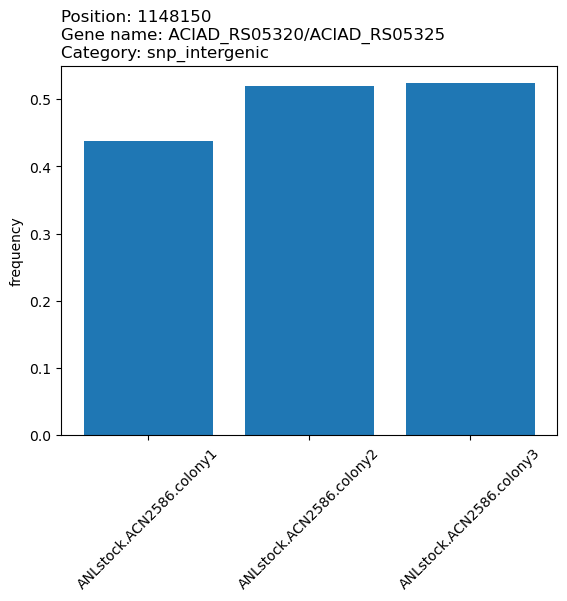

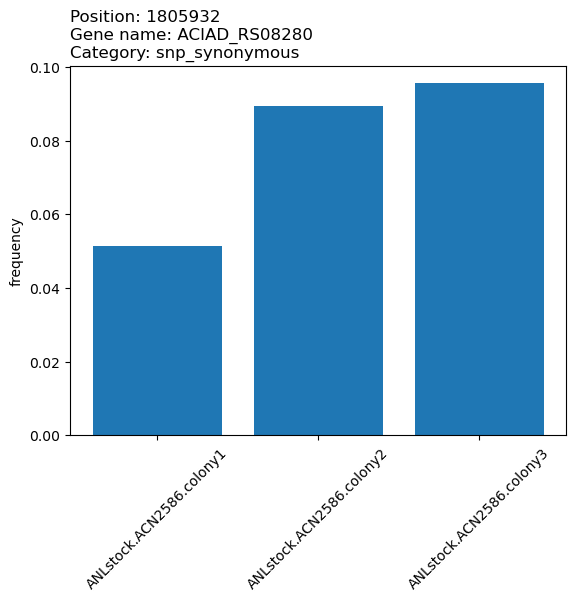

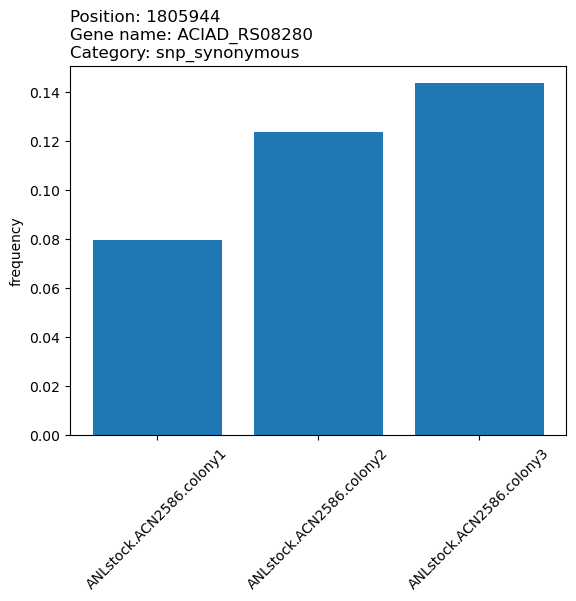

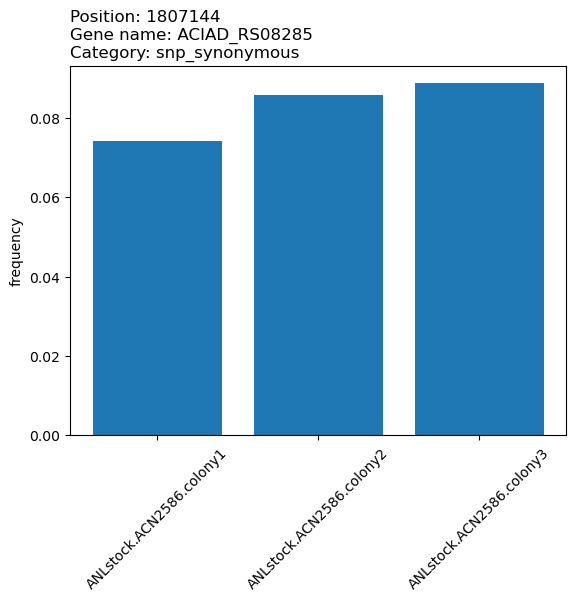

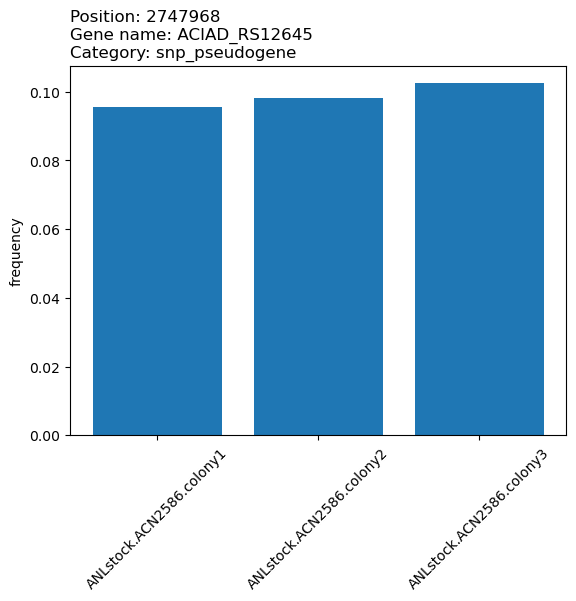

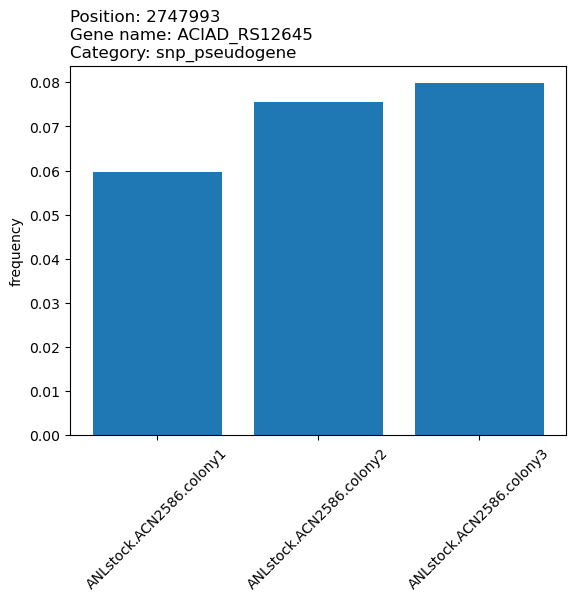

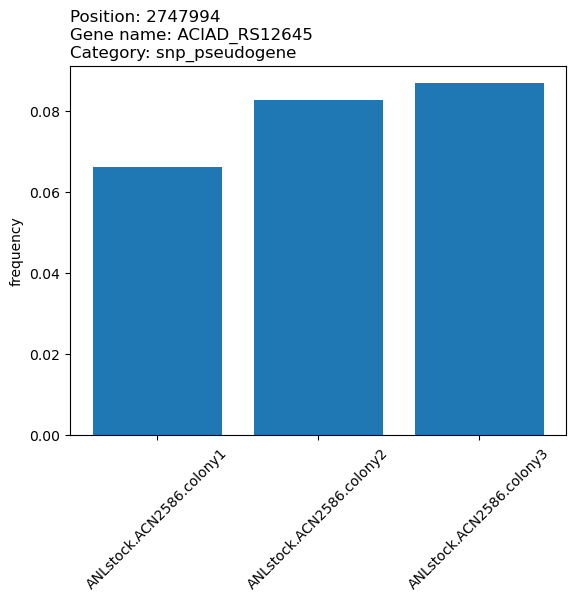

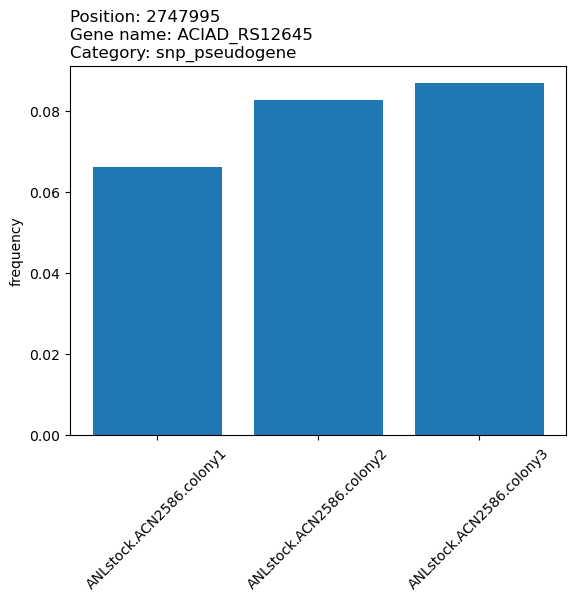

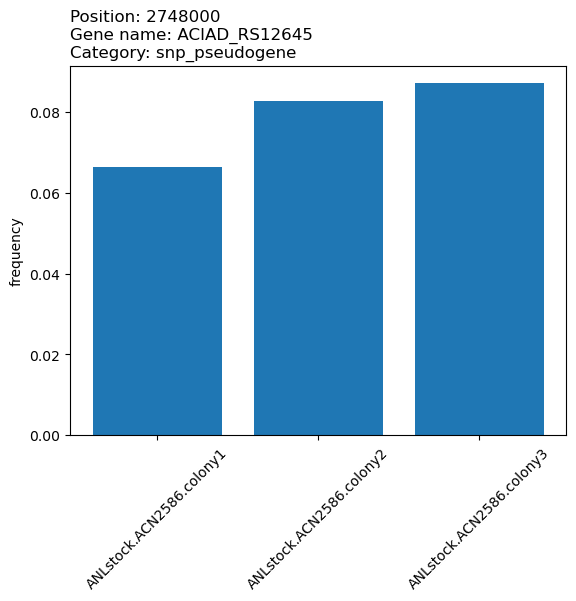

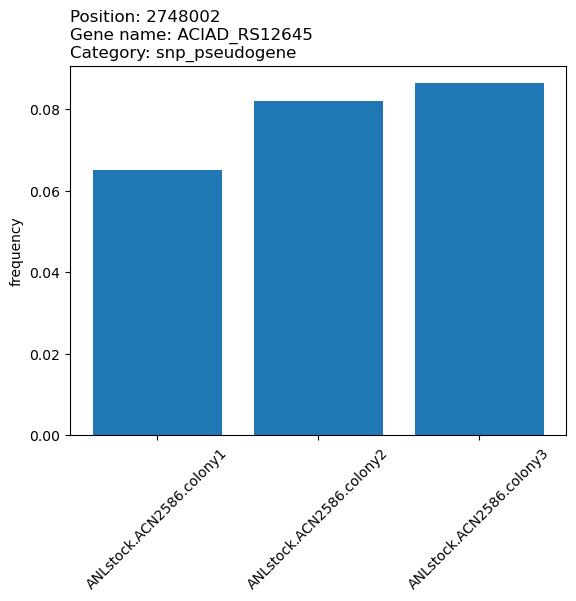

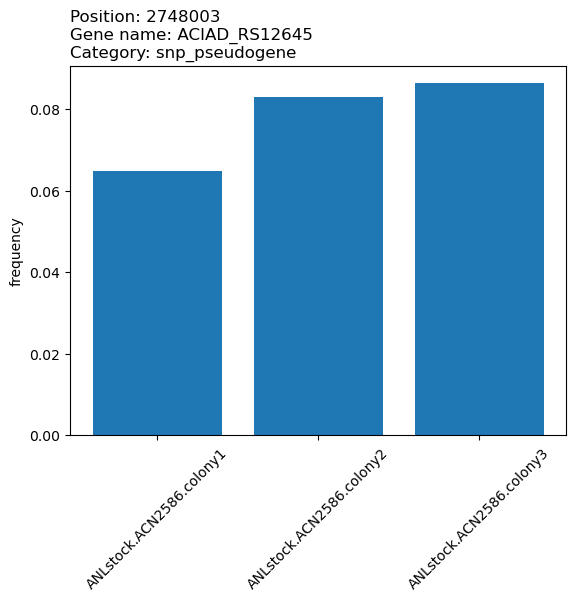

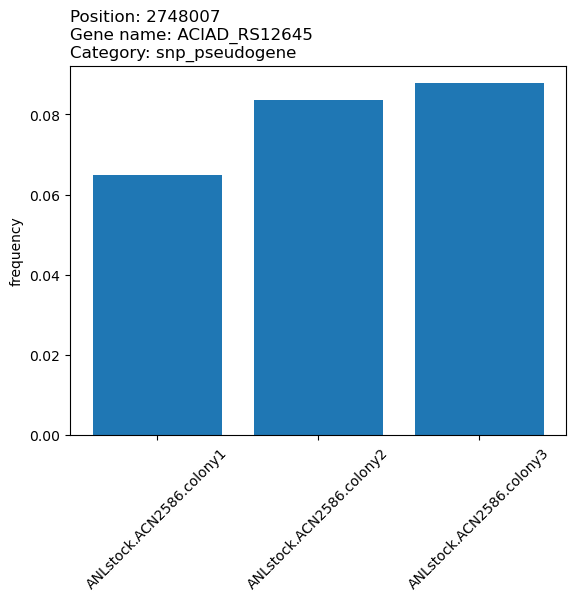

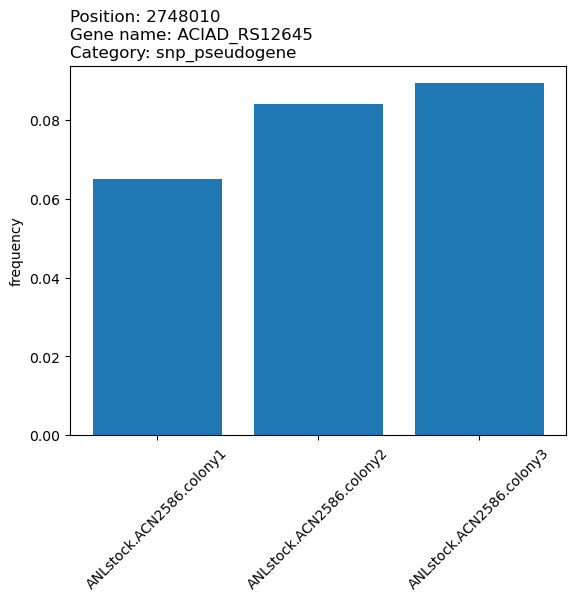

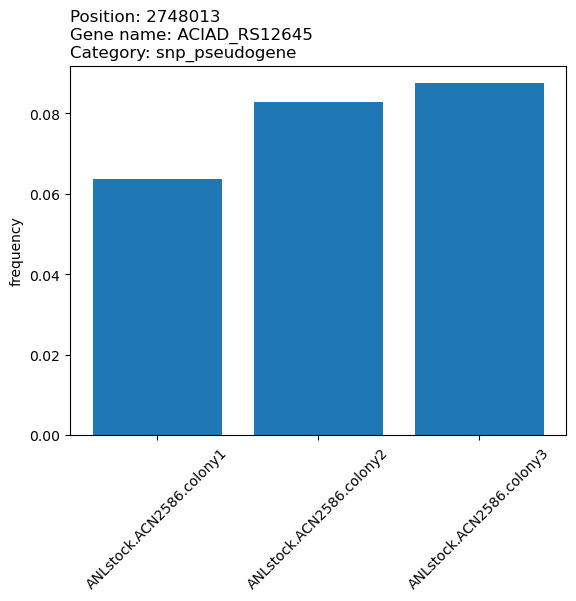

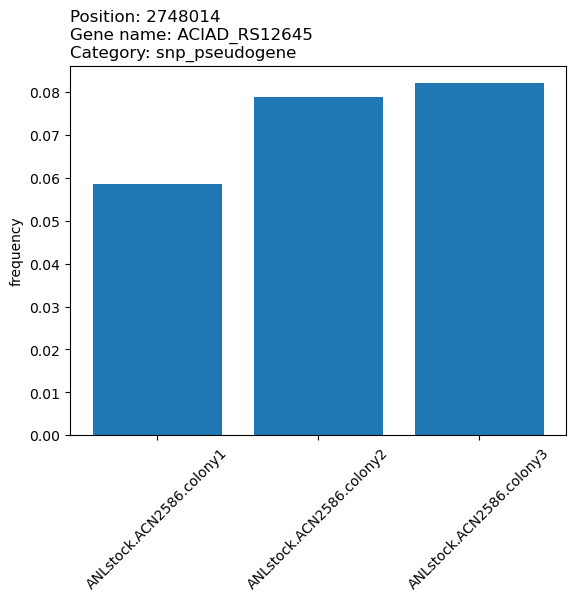

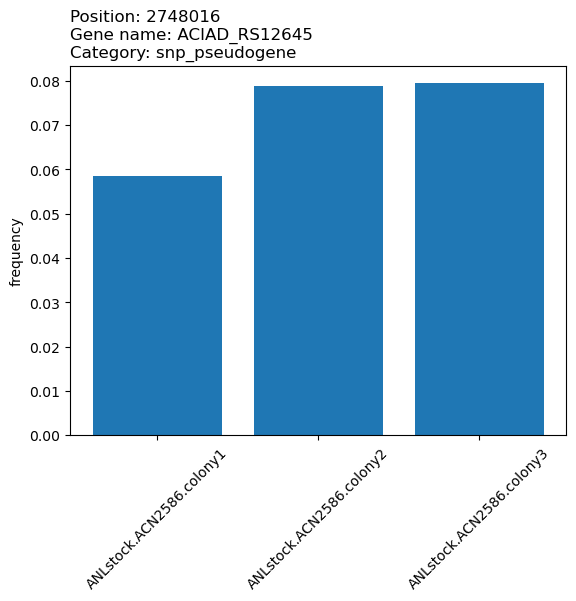

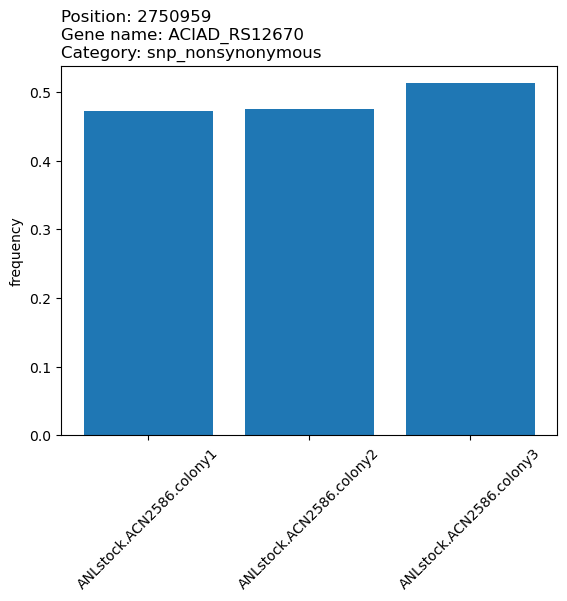

In [525]:
import matplotlib.pyplot as plt

for index, row in incr.iterrows():
    title = f"Position: {row['position']}\nGene name: {row['gene_name']}\nCategory: {row['mutation_category']}" 
    plt.bar(samples, row[samples])
    plt.xticks(rotation=45)
    plt.title(title, loc="left")
    plt.ylabel('frequency')
    plt.show()

In [595]:
from aisynbiopipeline.limsapi.config import load_config
from aisynbiopipeline.limsapi.sync import configure_logging

# logger = configure_logging()

config = load_config()
config['sync']

{'interval_minutes': 10,
 'enabled': True,
 'log_level': 'INFO',
 'log_file': '/storage/synbio/sync.log'}

In [610]:
# Check if the daemon is already running

from aisynbiopipeline.limsapi.sync import stop_sync_daemon, start_sync_daemon, sync_all_sheets

stop_sync_daemon()

In [604]:
# Check if the daemon is already running

from aisynbiopipeline.limsapi.sync import stop_sync_daemon, start_sync_daemon, sync_all_sheets

start_sync_daemon()

2025-12-17 21:04:55,652 - lims_sync - INFO - Sync daemon started with 10 minute interval
2025-12-17 21:04:55,656 - lims_sync - INFO - Starting sync operation
2025-12-17 21:04:55,656 - lims_sync - INFO - Connecting to Google Sheets
2025-12-17 21:04:56,154 - lims_sync - INFO - Connecting to database
2025-12-17 21:04:56,272 - lims_sync - INFO - Found 12 worksheets: Experiments, Strains, Conditions, Samples, Measurements, Genes, Measurement_types, DNA_constructs, Primers, dgoA_alleles_new, dgoA_alleles_old, robotic_mt_samples
2025-12-17 21:04:56,274 - lims_sync - INFO - Syncing worksheet: Experiments
2025-12-17 21:04:56,867 - lims_sync - INFO - Retrieved 9 rows from Experiments
2025-12-17 21:04:56,899 - lims_sync - INFO - Inserted 9, updated 0 rows in Experiments
2025-12-17 21:05:02,065 - lims_sync - INFO - Syncing worksheet: Strains
2025-12-17 21:05:02,759 - lims_sync - INFO - Retrieved 1020 rows from Strains
2025-12-17 21:05:02,824 - lims_sync - INFO - Inserted 1020, updated 0 rows in St

In [609]:
from aisynbiopipeline.limsapi.sync import _daemon_thread, _daemon_running, _sync_status
_daemon_running
# _sync_status

True

In [605]:
from aisynbiopipeline.limsapi.sync import _daemon_thread, _daemon_running, _sync_status
# _daemon_running
_sync_status

{'last_sync': '2025-12-17T21:03:07.922677',
 'last_success': '2025-12-17T21:03:07.922677',
 'last_error': "Sync failed: 'str' object has no attribute 'exists'",
 'syncs_completed': 686,
 'syncs_failed': 5}

In [571]:
from aisynbiopipeline.limsapi.config import get_credentials_path
from aisynbiopipeline.limsapi.config import load_config

config = load_config()
get_credentials_path(config)

creds_file: credentials/service_account.json


PosixPath('/home/nspahr/code/AISynbioPipeline/credentials/service_account.json')

In [542]:
query_lims('Experiments')

,Database_ID,Name,Type,Protocol,Start_timestamp,Description,Report,Error,deleted,last_synced,row_hash
0,,ALE1b,robotic ALE,ALE1b sample processing,4/4/2025,ALE1b was designed as a proof-of-principle tes...,ALE1b Report,,0,2025-11-14T23:45:28.127262,12b692454937a8256e7ed82c809b3c9f9c64b7db471f9e...
1,,strain_stocks,strain stock testing,NA,5/3/2024,Mock experiment that serves as collection of a...,,,0,2025-11-14T23:45:28.127721,b4500a63abc27a8d2c9d7616a46926f61759e727d4dd51...
2,,TFMN1,robotic mutant competition assay,TFMN1_protocol,10/8/2025,,,incomplete,0,2025-11-14T23:45:28.127755,729503566015225f4430b0f06cf8f4ad4f608b936498bc...
3,,DGOA_EASy,EASy and EASy isolates,EASy_protocol,4/1/2024,Prototrophic selection of strains with dgoA al...,,,0,2025-11-14T23:45:28.127781,9d1b1cb9ef02ce144c7a245c99711b31933c4dcf847041...
4,,ANL_UGA_prot_1,inter lab comparison,,,Comparison of proteomics results from ADP1 sam...,,incomplete,0,2025-11-14T23:45:28.127804,ee6fe35188ca21ab662e40885c83faceb38edf94cd15aa...
...,...,...,...,...,...,...,...,...,...,...,...
4548,,DGOA_EASy,EASy and EASy isolates,EASy_protocol,4/1/2024,Prototrophic selection of strains with dgoA al...,,,0,2025-12-17T17:20:34.108407,9d1b1cb9ef02ce144c7a245c99711b31933c4dcf847041...
4549,,ANL_UGA_prot_1,inter lab comparison,,,Comparison of proteomics results from ADP1 sam...,,incomplete,0,2025-12-17T17:20:34.108421,ee6fe35188ca21ab662e40885c83faceb38edf94cd15aa...
4550,,ANL_UGA_prot_2,inter lab comparison,,3/26/2025,Repeat experiment of ANL_UGA_prot_1 after stan...,,incomplete,0,2025-12-17T17:20:34.108433,549ebfba9657ff2af1d1e26aa7a411ec51963eb5eac8bf...
4551,,ANL_prot_3,proteomics standardization,,12/9/2025,Comparison of proteomics results for multiple ...,,incomplete,0,2025-12-17T17:20:34.108443,20e663b9f747d30e643d4ada5d6b463aba614eb80adb33...


In [546]:
exp = query_lims('Experiments')
exp.iloc[4544]['row_hash'] == exp.iloc[4552]['row_hash']

True

In [566]:
exp['row_hash'].nunique()

8

In [552]:
query_lims('Experiments').tail(20)

,Database_ID,Name,Type,Protocol,Start_timestamp,Description,Report,Error,deleted,last_synced,row_hash
4542,,ANL_UGA_prot_2,inter lab comparison,,3/26/2025,Repeat experiment of ANL_UGA_prot_1 after stan...,,incomplete,0,2025-12-17T17:15:40.138758,549ebfba9657ff2af1d1e26aa7a411ec51963eb5eac8bf...
4543,,ANL_prot_3,proteomics standardization,,12/9/2025,Comparison of proteomics results for multiple ...,,incomplete,0,2025-12-17T17:15:40.138785,20e663b9f747d30e643d4ada5d6b463aba614eb80adb33...
4544,,ANL_prot_4,proteome characterization,,12/16/2025,Characterizing the proteome of ACN3560 (colony...,,incomplete,0,2025-12-17T17:15:40.138811,730c7cc8665b443dcc8e4bcc38889fdc63170b31e43d74...
4545,,ALE1b,robotic ALE,ALE1b sample processing,4/4/2025,ALE1b was designed as a proof-of-principle tes...,ALE1b Report,,0,2025-12-17T17:20:34.101663,12b692454937a8256e7ed82c809b3c9f9c64b7db471f9e...
4546,,strain_stocks,strain stock testing,NA,5/3/2024,Mock experiment that serves as collection of a...,,,0,2025-12-17T17:20:34.108362,b4500a63abc27a8d2c9d7616a46926f61759e727d4dd51...
4547,,TFMN1,robotic mutant competition assay,TFMN1_protocol,10/8/2025,,,incomplete,0,2025-12-17T17:20:34.108390,729503566015225f4430b0f06cf8f4ad4f608b936498bc...
4548,,DGOA_EASy,EASy and EASy isolates,EASy_protocol,4/1/2024,Prototrophic selection of strains with dgoA al...,,,0,2025-12-17T17:20:34.108407,9d1b1cb9ef02ce144c7a245c99711b31933c4dcf847041...
4549,,ANL_UGA_prot_1,inter lab comparison,,,Comparison of proteomics results from ADP1 sam...,,incomplete,0,2025-12-17T17:20:34.108421,ee6fe35188ca21ab662e40885c83faceb38edf94cd15aa...
4550,,ANL_UGA_prot_2,inter lab comparison,,3/26/2025,Repeat experiment of ANL_UGA_prot_1 after stan...,,incomplete,0,2025-12-17T17:20:34.108433,549ebfba9657ff2af1d1e26aa7a411ec51963eb5eac8bf...
4551,,ANL_prot_3,proteomics standardization,,12/9/2025,Comparison of proteomics results for multiple ...,,incomplete,0,2025-12-17T17:20:34.108443,20e663b9f747d30e643d4ada5d6b463aba614eb80adb33...


In [608]:
len(query_lims('Measurements'))

789306

In [601]:
len(query_lims('Experiments'))

4670